# **Glassdoor Employee Reviews - Exploratory Data Analysis**

---------------------------------------
## **1. Introduction**

#### 1.1 Overview

This project aims to analyze employee reviews to understand overall workplace satisfaction, identify key drivers of positive and negative sentiment, and examine whether perceptions differ between current and former employees.

#### 1.2 Original Data Source
source: https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews

#### 1.3 Problem Statement

How do employees perceive their workplaces, and what factors most strongly influence overall satisfaction?

#### 1.4 Objectives

- Examine trends in average overall employee ratings across the years.
- Compare overall ratings between current and former employees.
- Use text analysis to identify recurring themes in employee reported pros and cons.
- Compare recommendation percentages among the top 10 most reviewed companies.

#### 1.5 Data Dictionary

| **Column** | **Type** | **Description** |
| --- | --- | ---|
| `firm` | str | Name of the company being reviewed. |
| `date_review` | datetime | Date on which the employee submitted the review. |
| `job_title` | str | Job position held by the employee |
| `employment_status` | str | Employment status of the reviewer (e.g., current, former). |
| `location` | str | Geographic location where the employee worked. |
| `overall_rating` | int | Overall satisfaction rating given by the employee (1–5 scale). |
| `work_life_balance` | float | Rating of work life balance at the company (1–5 scale). |
| `culture_values` | float | Rating of work-life balance at the company (1–5 scale). |
| `career_opp` | float | Rating of career growth and advancement opportunities (1–5 scale). |
| `comp_benefits` | float | Rating of compensation and benefits (1–5 scale). |
| `senior_mgmt` | float | Rating of compensation and benefits (1–5 scale). |
| `recommend` | category | Employee’s recommendation sentiment (Positive, Negative, No Opinion). |
| `ceo_approv` | category | Employee sentiment regarding CEO approval (Positive, Mild, Negative, No Opinion). | 
| `outlook` | category | Employee outlook on the company’s future (Positive, Mild, Negative, No Opinion). |
| `headline` | str | Short summary title of the employee’s review. |
| `pros` | str | Describing positive aspects of working at the company. |
| `cons` | str | Describing positive aspects of working at the company. |
| `year` | int | Year extracted from `date_review` for time based analysis. |
| `employment_status_clean` | category | Standardized employment status (Current or Former) used for analysis. |

----------------------------------------------------
## **2. Data Overview**

In [74]:
import pandas as pd

df= pd.read_csv(r"C:\Users\alial\PythonDAB21\glassdoor_reviews.csv\glassdoor_reviews.csv")

In [75]:
df.shape # The data set contains 838566 rows and 18 columns (rows, columns)

(838566, 18)

In [76]:
df.columns # Displaying the column names

Index(['firm', 'date_review', 'job_title', 'current', 'location',
       'overall_rating', 'work_life_balance', 'culture_values',
       'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt',
       'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons'],
      dtype='str')

In [77]:
df.info() # Checking the data types and the non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 838566 entries, 0 to 838565
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   firm                 838566 non-null  str    
 1   date_review          838566 non-null  str    
 2   job_title            838566 non-null  str    
 3   current              838566 non-null  str    
 4   location             541223 non-null  str    
 5   overall_rating       838566 non-null  int64  
 6   work_life_balance    688672 non-null  float64
 7   culture_values       647193 non-null  float64
 8   diversity_inclusion  136066 non-null  float64
 9   career_opp           691065 non-null  float64
 10  comp_benefits        688484 non-null  float64
 11  senior_mgmt          682690 non-null  float64
 12  recommend            838566 non-null  str    
 13  ceo_approv           838566 non-null  str    
 14  outlook              838566 non-null  str    
 15  headline             835976 

In [78]:
df.isnull().sum() # Displaying the number of the missing values per column

firm                        0
date_review                 0
job_title                   0
current                     0
location               297343
overall_rating              0
work_life_balance      149894
culture_values         191373
diversity_inclusion    702500
career_opp             147501
comp_benefits          150082
senior_mgmt            155876
recommend                   0
ceo_approv                  0
outlook                     0
headline                 2590
pros                        2
cons                       13
dtype: int64

In [79]:
df.describe() # Showing statistics summary such as average, median etc for numerical columns

,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt
count,838566.000000,688672.000000,647193.000000,136066.000000,691065.000000,688484.000000,682690.000000
mean,3.655956,3.375735,3.590164,3.966612,3.461825,3.398109,3.176576
std,1.174684,1.305874,1.323280,1.190937,1.271295,1.218738,1.330720
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [80]:
df.sample(5) # Displaying 5 random rows to help understand the structure

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
801733,University-of-Manchester,2021-05-31,Head of Acceleration,"Current Employee, more than 3 years","Manchester, England, England",5,NaN,NaN,NaN,NaN,NaN,NaN,v,o,v,Awesome community,"Like minded, driven people\r\nFree office in a...","Being a student organisation, we received no s..."
554974,McKinsey-and-Company,2016-09-30,,Current Employee,NaN,5,3.0,5.0,NaN,5.0,5.0,5.0,v,v,v,One of the best to work for,"Company is centered around employees, awesome ...",Long shifts may easily cause strain and stress
160552,Countrywide-plc,2016-11-16,Customer Relations Advisor,"Current Employee, more than 1 year","Cheadle, North West England, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,r,x,Low Pay High Expectations,"Undervalued colleagues are good people, but th...","Very low pay, no real benefits, no progression..."
515247,McDonald-s,2016-08-29,,Former Employee,NaN,5,NaN,NaN,NaN,5.0,5.0,NaN,o,o,o,cashier,good food and you get a meal everyday,you get no respect from others.
155373,Co-op,2015-01-12,Loan Processor,"Current Employee, more than 3 years",Carigara,4,3.0,4.0,NaN,3.0,3.0,4.0,v,o,v,People helping people.,At this cooperative we think about ourselves a...,I am not comfortable until I complete my work ...


-------------------------------------------------
## **3. Data Cleaning**

### 3.1 Renaming `current`

In [81]:
# Renaming the "column" to "employment_status" to better reflect its meaning

df= df.rename(columns= {"current":"employment_status"})

### 3.2 Converting `date_review`

In [82]:
df["date_review"]= pd.to_datetime(df["date_review"]) # Converting the date_review column from str to datetime

### 3.3 Adding a New `year` Column

In [83]:
# Adding a new "year" column to help us analyze how employee ratings change over the years

df["year"]= df["date_review"].dt.year

### 3.4 Converting Letter Based Category Codes to Descriptive Labels

According to the dataset documentation on Kaggle, the data in the columns `recommend`, `ceo_approv`, and `outlook` were stored as the the following letter based
category codes:

- v ---> Positive
- r ---> Mild
- x ---> Negative
- o ---> No opinion

**For clarity and readability in analysis and visualization, I converted these letters to their corresponding descriptive text labels.**

Unlike the other rating columns, which use a 1–5 numerical scale, these columns represent general opinion categories rather than detailed ratings. For example, in a numerical rating system, a low score could be 1 or 2, showing different levels of dissatisfaction. In contrast, this categorical system only includes a single “Negative” option, without distinguishing between degrees of negativity. Because of this difference in structure, I kept these columns as categorical instead of converting them to numerical.

In [84]:
# Using a dictionary to map each letter to it's corresponding category label

df[["recommend", "ceo_approv", "outlook"]]= df[["recommend", "ceo_approv", "outlook"]].replace({
    "v":"Positive",
    "r":"Mild",
    "x":"Negative",
    "o":"No opinion"
})

In [85]:
# Converting the recommend, ceo_approv, and outlook columns to from str to category

df[["recommend", "ceo_approv", "outlook"]]= df[["recommend", "ceo_approv", "outlook"]].astype("category")

### 3.5 Handling Duplicates

In [86]:
# Let's count how many duplicates are there

df.duplicated().sum()

np.int64(33515)

In [87]:
# Let's drop the duplicates

df= df.drop_duplicates()

### 3.6 Removing Extra Spaces

In [88]:
# Since strip only works on string columns...
# I used .dtypes to check which of the columns are in string format.
# There are 7 total columns in string format

# note: the employment_category is shown as category but it was previously str

df.dtypes

firm                              str
date_review            datetime64[us]
job_title                         str
employment_status                 str
location                          str
overall_rating                  int64
work_life_balance             float64
culture_values                float64
diversity_inclusion           float64
career_opp                    float64
comp_benefits                 float64
senior_mgmt                   float64
recommend                    category
ceo_approv                   category
outlook                      category
headline                          str
pros                              str
cons                              str
year                            int32
dtype: object

In [89]:
# The .str.strip() method only works on series, not directly on dataframes, so I applied it to each series separately

df["firm"]= df["firm"].str.strip()

df["employment_status"]= df["employment_status"].str.strip()

df["job_title"]= df["job_title"].str.strip()

df["location"]= df["location"].str.strip()

df["headline"]= df["headline"].str.strip()

df["pros"]= df["pros"].str.strip()

df["cons"]= df["cons"].str.strip()

### 3.7 Handling Nulls

In [90]:
# Now that we removed the extra spaces, we can replace all blanks with NaN

df= df.replace("", pd.NA)

In [91]:
# Replacing common text representations of missing values with proper NaN

df= df.replace(["N/A", "N/a", "n/a"], pd.NA)

In [92]:
# To decide whether to drop a column or not... 
# Let's calculate percentage of missing values for each column:

# I made a variable named null_percentage
# The df.isna() checks which values are missing (True/False)
# The .mean() is used to calculate the proportion of the missing values
# Finally, we will multipy the mean by 100 to get the percentage

null_percentage = df.isna().mean() * 100

# Sort from highest to lowest so the columns with the highest nulls will show on top

null_percentage.sort_values(ascending=False)

diversity_inclusion    83.741279
location               35.413284
culture_values         22.776694
senior_mgmt            18.608014
comp_benefits          17.917126
work_life_balance      17.894518
career_opp             17.604599
job_title               9.432570
headline                0.324079
cons                    0.001863
pros                    0.000248
date_review             0.000000
firm                    0.000000
employment_status       0.000000
overall_rating          0.000000
outlook                 0.000000
ceo_approv              0.000000
recommend               0.000000
year                    0.000000
dtype: float64

In [93]:
# dropping the "diversity_inclusion" column

df= df.drop(columns= ["diversity_inclusion"])

The `diversity_inclusion` column has ~84% missing values. This high level of missing data significantly limits its analytical
usefulness. Therefore, I removed this column from further analysis.

Possible reasons for the many missing entries:

- The metric may have been introduced later since the older reviews had more missing values than the recent ones.
- It may not be available for all companies/regions

### 3.8 Standardizing `employment_status`

In [94]:
# Let's check how many unique categories exist in the employment_status column (including the messy ones)

df["employment_status"].nunique()

29

In [95]:
# Let's display all the categories and how common they are

df["employment_status"].value_counts()

employment_status
Current Employee                           200578
Former Employee                            140754
Current Employee, more than 1 year          79431
Current Employee, more than 3 years         63636
Former Employee, more than 1 year           63469
Current Employee, less than 1 year          47932
Former Employee, more than 3 years          41877
Former Employee, less than 1 year           40834
Current Employee, more than 5 years         38306
Current Employee, more than 10 years        23631
Former Employee, more than 5 years          22069
Current Employee, more than 8 years         17664
Former Employee, more than 10 years         14603
Former Employee, more than 8 years          10235
Former Contractor, less than 1 year             6
Former Intern, less than 1 year                 5
Current Contractor, less than 1 year            3
Current Contractor, more than 1 year            3
Former Contractor                               2
Current Contractor              

The `employment_status` column contains many inconsistent labels (29 unique values), including errors like
("KEY NOT FOUND..."). Since my analysis will compare Current vs Former employees, this column will be standardized into two categories: Current and Former. Values that do not clearly match either category will be treated as missing.

In [96]:
# I created a new column so the original values are perserved for reference

df["employment_status_clean"]= df["employment_status"]

In [97]:
# Standardizing any value value containing the word "Current"

df.loc[
    df["employment_status_clean"].str.contains("Current"), "employment_status_clean"
]= "Current"

In [98]:
# Standardizing any value value containing the word "Former"

df.loc[
    df["employment_status_clean"].str.contains("Former"), "employment_status_clean"
]= "Former"

In [99]:
# Replacing the error messages with nan

df.loc[
    df["employment_status_clean"].str.contains("KEY NOT FOUND"), "employment_status_clean"
]= pd.NA

In [100]:
# Dropping the rows with the error message "KEY NOT FOUND"

# Since only 3 such rows exist, removing them will not impact the overall analysis

df= df.dropna(subset= ["employment_status_clean"])

In [101]:
# Converting the employment_status_clean column from str to category

df["employment_status_clean"]= df["employment_status_clean"].astype("category")

-------------------------------------
## **4. Analysis & Insights**

### 4.1 Overall Ratings Over the Years

In [102]:
# I will group the dataset by year and focus only on the 'overall_rating' column
# For each year, I will calculate the average rating
# Then sort the results in order

rating_by_year = df.groupby("year")["overall_rating"].agg(["mean"]).sort_index()

rating_by_year

,mean
year,
2008,3.454121
2009,3.268207
2010,3.205185
2011,3.285244
2012,3.508564
2013,3.468323
2014,3.404297
2015,3.494932
2016,3.573348


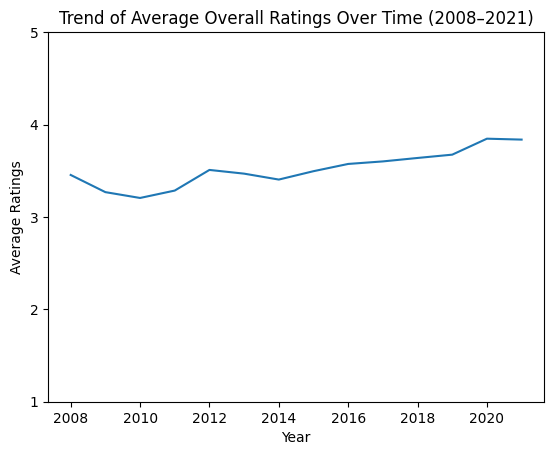

In [103]:
# Plotting the average overall rating per year as a line chart

rating_by_year.plot(
    y="mean", 
    kind="line",
    ylabel="Average Ratings", 
    xlabel="Year", 
    yticks=[1, 2, 3, 4, 5],
    legend= False,
    title="Trend of Average Overall Ratings Over Time (2008–2021)");

**Key Insights:**

- Employee satisfaction remains stable over the years
- Ratings fluctuate slightly but stay within the narrow range of 3 to 4
- The overall sentiment is moderately positive across all years
- This tells us the companies are not failing dramatically but they're also not achieving extremely high satisfaction

### 4.2 Current vs Former Employees Comparison

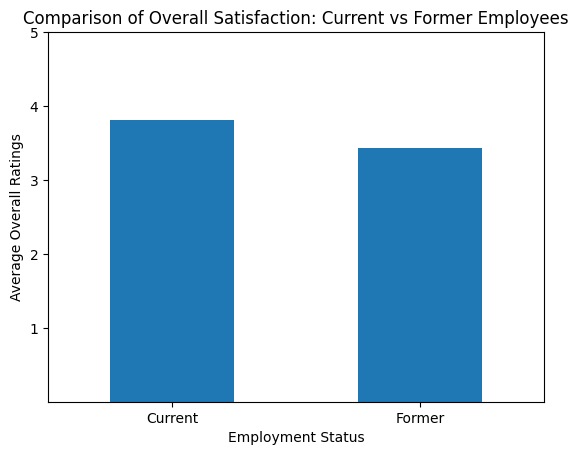

In [104]:
df.groupby("employment_status_clean")["overall_rating"].mean().plot(
    kind="bar", 
    ylabel= "Average Overall Ratings", 
    xlabel= "Employment Status",
    title= "Comparison of Overall Satisfaction: Current vs Former Employees",
    yticks= [1, 2, 3, 4, 5], 
    rot= 0);

**Key Insights:**

- Current employees report higher overall satisfaction compared to former employees
- While the difference is moderate, it suggests that employees who leave experience lower workplace satisfaction prior to leaving the company

### 4.3 Pros and Cons Text Analysis

In [105]:
# installing the wordcloud library

!pip install wordcloud


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


-------------------------------------------
**`pros` Column Text Analysis:**

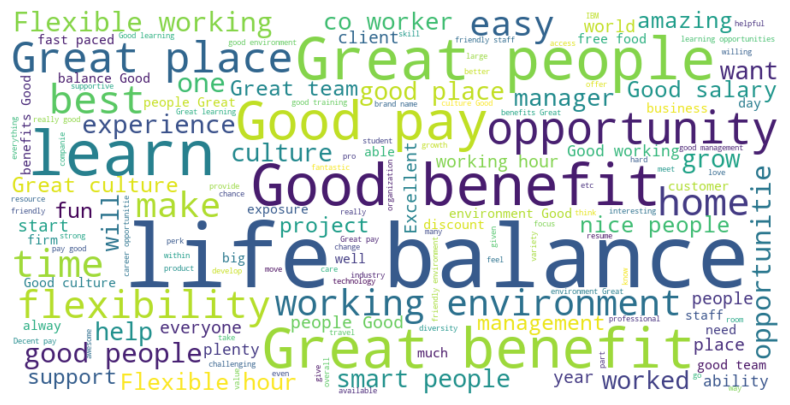

In [106]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1) Combine all text from the 'pros' column into one big string
#    - dropna() removes missing values so WordCloud doesn't break
pros_text = " ".join(df["pros"].dropna().astype(str))

# 2) Set up stopwords (words we don't want, like "the", "and", etc.)
stopwords = set(STOPWORDS)

# Add a few common “non-informative” words for this dataset
stopwords.update(["company","work", "employee", "employees", "job", "role", "lot", "lots"])

# 3) Create the word cloud
pros_wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=stopwords,
    max_words=150
).generate(pros_text)

# 4) Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(pros_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

**Key Insights:**


**1. Work life balance and flexibility are major strengths**
- Large words: life balance, flexible working, time.
- This suggests that employees frequently highlight flexibility and work life balance as key positive aspects of their experience.

**2. Compensation and benefits are highly mentioned**
- Large words: great benefit, good pay
- Compensation and benefits are commonly cited strengths, suggesting financial rewards are an important driver of positive sentiment.

**3. Learning and growth opportunities**
- Large words: learn, opportunity, grow
- Professional development and learning opportunities are commonly highlighted as positive aspects of employment.

---------------------
**`cons` Column Text Analysis:**

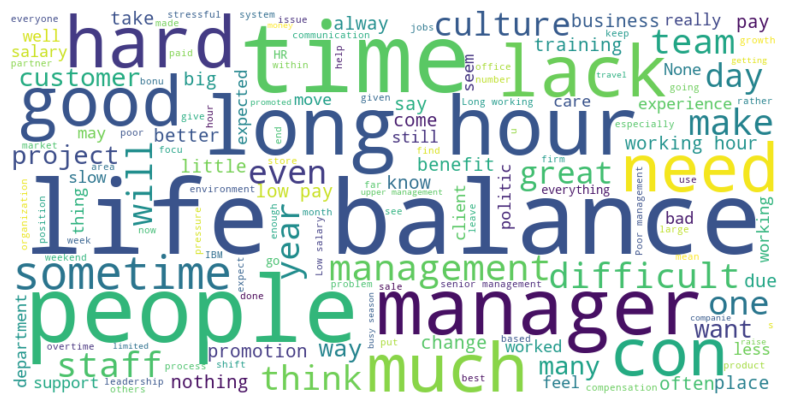

In [107]:
# 1) Combine all text from the 'cons' column into one big string
#    - dropna() removes missing values so WordCloud doesn't break
cons_text = " ".join(df["cons"].dropna().astype(str))

# 2) Set up stopwords (common words we don't want, like "the", "and", etc.)
stopwords = set(STOPWORDS)

# Optional: add a few common “non-informative” words for this dataset
stopwords.update(["company", "work", "employee", "employees", "job", "role", "lot", "lots"])

# 3) Create the word cloud
cons_wc = WordCloud(
    width=900,
    height=450,
    background_color="white",
    stopwords=stopwords,
    max_words=150
).generate(cons_text)

# 4) Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(cons_wc, interpolation="bilinear")
plt.axis("off")
plt.show()

**Key Insights:**

**1. Long Hours & Workload Pressure**

- Large words: life balance, long hour, time.
- Employees frequently mention long working hours and heavy workload as negative aspects of employemnt.

**2. Management is a dominant negative theme**

- Large words: management, manager.
- Management related concerns are a big theme in negative reviews, indicating that leadership may be a major source of dissatisfaction.

**3. Compensation concerns appear, but not dominant**

- Words: low pay, salary pay.
- While pay and salary are mentioned in negative reviews, they are not as prominent as concerns about management or workload, suggesting that compensation may not be the primary source of dissatisfaction.

### 4.4 Top 10 Most Reviewed Companies Analysis

In this section, we will analyze the recommendation sentiment for the 10 most reviewed companies in the dataset. By focusing on the most reviewed firms, we ensure sufficient data volume for meaningful comparison. The “recommend” column reflects whether employees would recommend their company, which provides insight into overall employee advocacy and workplace satisfaction.

In [108]:
# Get the names of the 10 most reviewed companies

top_10 = df["firm"].value_counts().head(10).index

In [109]:
# Keep only rows belonging to the top 10 companies

top_df = df[df["firm"].isin(top_10)]

In [110]:
# Create a table of recommendation categories per company (as percentages)

recommend_pct = pd.crosstab(
    top_df["firm"],                # rows = company
    top_df["recommend"],           # columns = recommendation category
    normalize="index"              # convert counts into proportions per company
) * 100                            # convert proportions to percentages

recommend_pct = recommend_pct.reset_index()  # reset index for seaborn

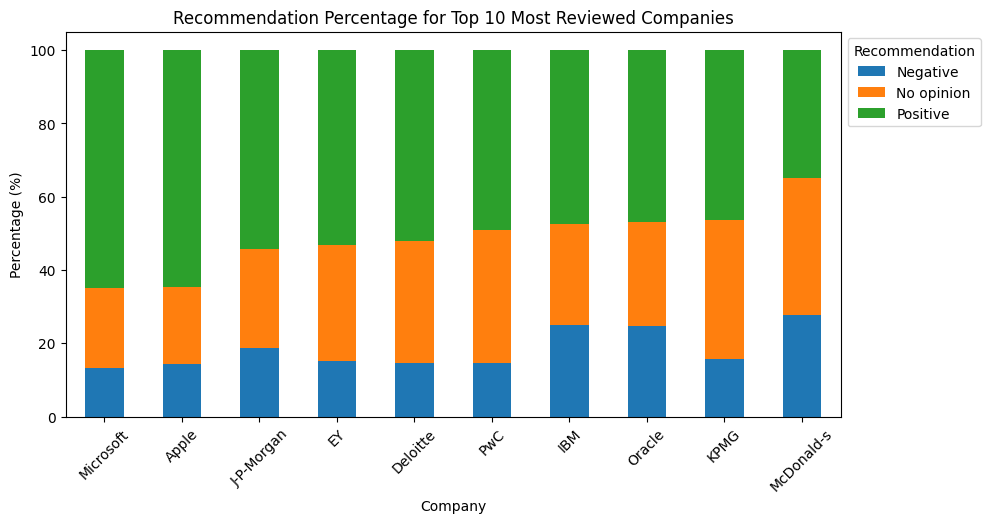

In [111]:
# Set the company name as the index so it appears on the x-axis
# Then create a stacked bar chart showing recommendation percentages

recommend_pct_sorted = recommend_pct.sort_values(by="Positive", ascending=False)
recommend_pct_sorted.set_index("firm").plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Recommendation Percentage for Top 10 Most Reviewed Companies")
plt.ylabel("Percentage (%)")
plt.xlabel("Company")
plt.xticks(rotation=45)

# Move legend above the plot
plt.legend(
    title="Recommendation",
    loc="upper left",
    bbox_to_anchor=(1, 1),
    ncol=1
)

plt.show()

**Key Insights:**

- Despite differences across companies, positive recommendations remain the dominant category for all top firms, reinforcing the overall moderately positive sentiment observed throughout the dataset.
- Microsoft and Apple show the highest percentage of positive recommendations among the top 10 most reviewed companies, which indicates strong employee advocacy.
- A noticeable portion of responses fall under “No opinion”, which suggests that employee sentiment is not strongly polarized.
- Although negative recommendations represent a smaller portion compared to positive responses, certain companies have a noticeably higher proportion of negative feedback. This suggests that employee dissatisfaction, while not dominant, remains a meaningful factor within some large organizations.

In [115]:
# Exporting the cleaned file as csv
# The "index= False" pandas from saving the row index as a separate column

df.to_csv("glassdoor_cleaned.csv", index=False)

-------------------------------------------------------
## **5. Limitations**

- The dataset includes over 400 companies across different industries, however, industry classification is not provided. This limits the ability to control for industry specific factors that may influence employee satisfaction.
- Some companies encourage (or pressure) employees to leave 5 star reviews to boost their corporate brand.
- The “No opinion” category may include neutral or disengaged employees, but its interpretation may vary between reviewers.

--------------------------
## **6. Conclusion**

- This analysis revealed that overall workplace satisfaction is moderately positive, with average overall ratings consistently ranging between 3 and 4.
- While current employees tend to rate their companies slightly higher than former employees, the differences are moderate rather than extreme.
- Word cloud analysis results show good pay and flexibility as strengths, while leadership and workload appear as recurring concerns.

-------------------------------
## **7. Recommendations**

- Focus on strengthening leadership communication, and management practices, as management related concerns appeared consistently in qualitative feedback.
- Evaluate workload distribution and work hour expectations to reduce employee stress and improve overall satisfaction.
- Continue investing in workplace culture, flexibility, and team dynamics, as these were frequently highlighted as positive aspects in employee reviews.